In [24]:
%matplotlib inline

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use("ggplot")

In [26]:
df = pd.read_csv("Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [27]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 10194
Columns : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost 

In [28]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [29]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


In [30]:
df["Gross Margin (%)"] = (df["Gross Profit"] / df["Sales"]) * 100

df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

df["Revenue Contribution"] = (
    df["Sales"] / df["Sales"].sum()
) * 100

df["Profit Contribution"] = (
    df["Gross Profit"] / df["Gross Profit"].sum()
) * 100

In [31]:
print("Total Sales :", round(df["Sales"].sum(),2))
print("Total Profit :", round(df["Gross Profit"].sum(),2))
print("Average Margin :", round(df["Gross Margin (%)"].mean(),2))
print("Average Profit per Unit :", round(df["Profit per Unit"].mean(),2))

Total Sales : 141783.63
Total Profit : 93442.8
Average Margin : 66.51
Average Profit per Unit : 2.41


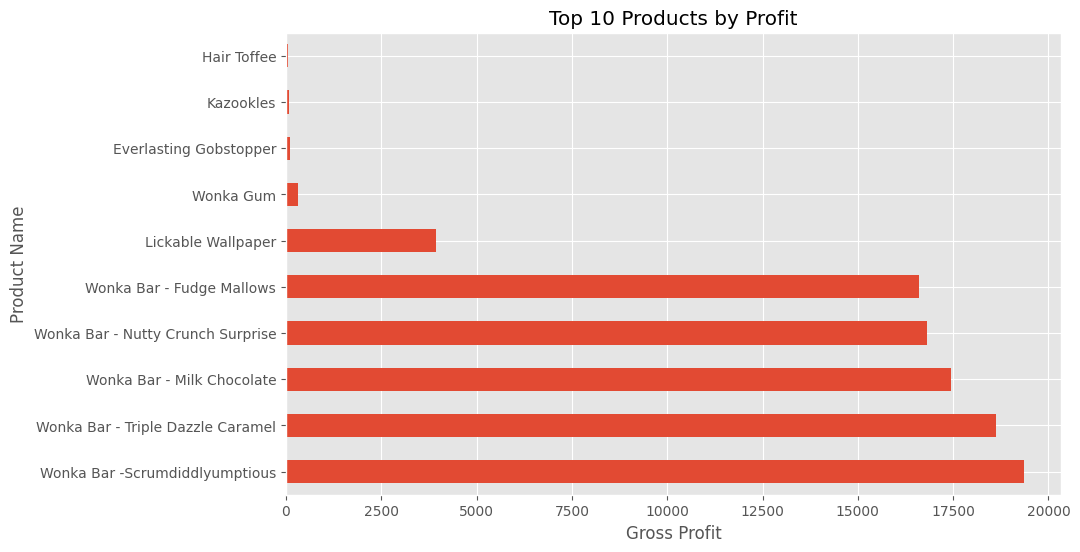

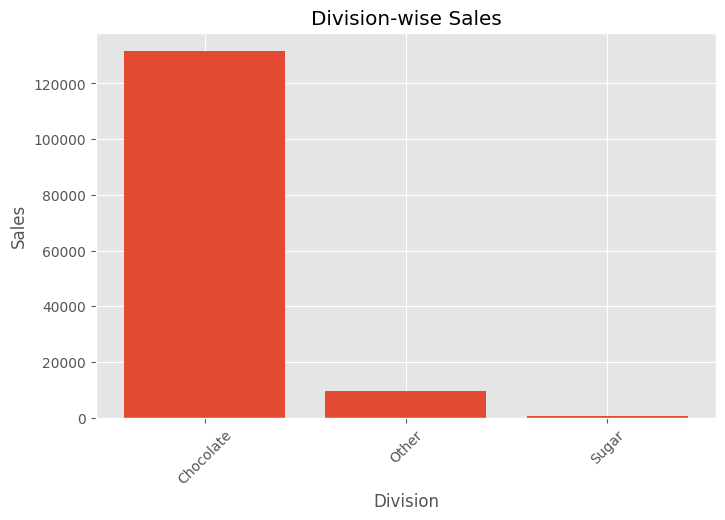

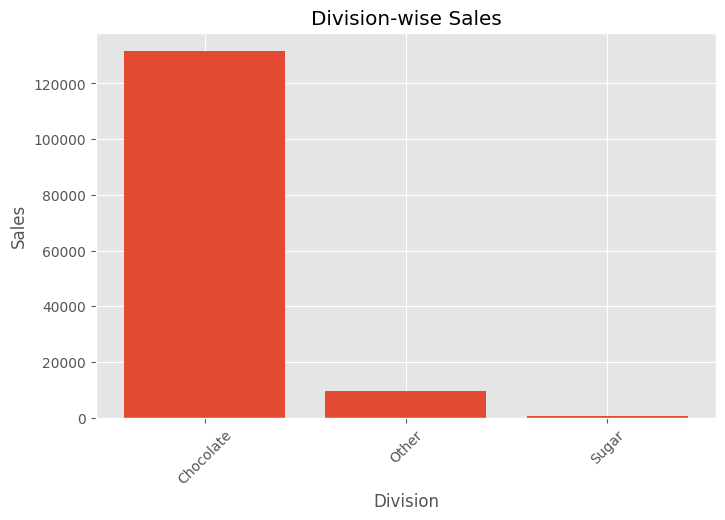

In [32]:
import matplotlib.pyplot as plt

division_sales = df.groupby("Division")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(division_sales["Division"], division_sales["Sales"])

plt.title("Division-wise Sales")
plt.xlabel("Division")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

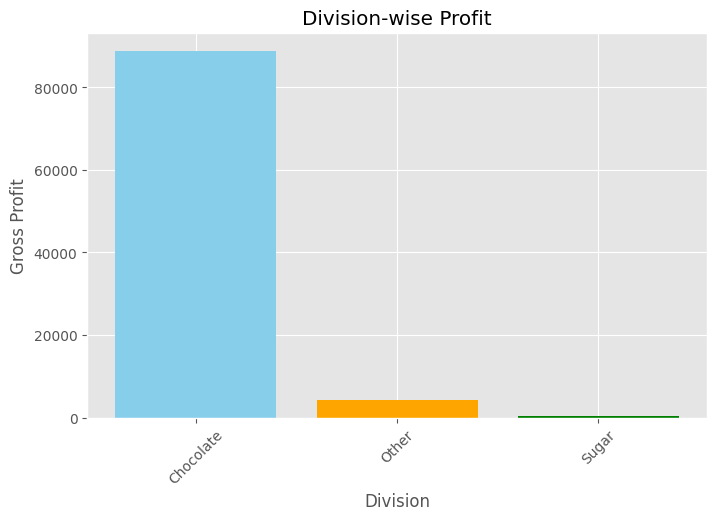

In [39]:
import matplotlib.pyplot as plt

# Group data by Division
division_profit = df.groupby("Division")["Gross Profit"].sum().reset_index()

# Different colors for each bar
colors = ["skyblue", "orange", "green"]

plt.figure(figsize=(8,5))
plt.bar(
    division_profit["Division"],
    division_profit["Gross Profit"],
    color=colors[:len(division_profit)]
)

plt.title("Division-wise Profit")
plt.xlabel("Division")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)

plt.show()

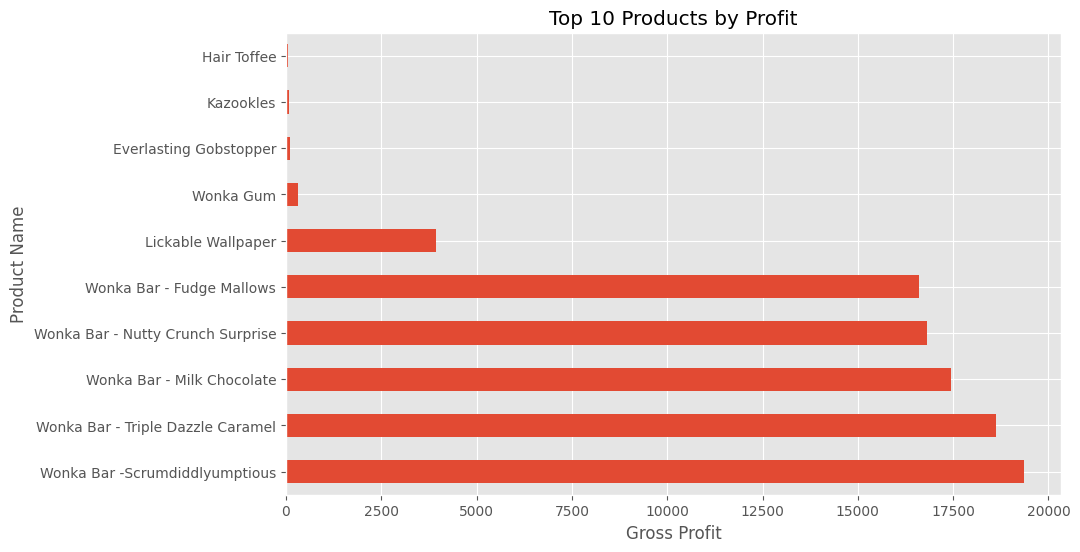

In [34]:
top_products = (
    df.groupby("Product Name")["Gross Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Gross Profit")
plt.show()

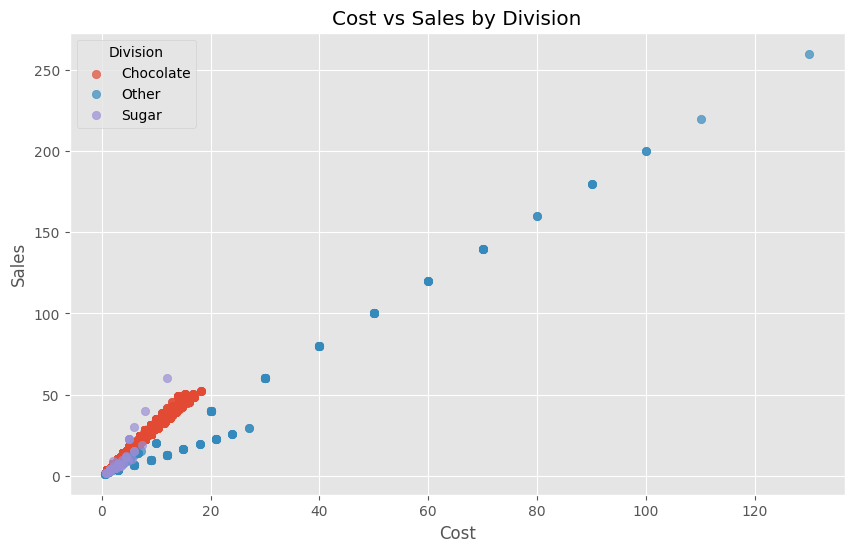

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plot each division with a different color
for division in df["Division"].unique():
    data = df[df["Division"] == division]
    plt.scatter(
        data["Cost"],
        data["Sales"],
        label=division,
        alpha=0.7
    )

plt.title("Cost vs Sales by Division")
plt.xlabel("Cost")
plt.ylabel("Sales")
plt.legend(title="Division")
plt.grid(True)

plt.show()